In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving API_NY.GDP.PCAP.CD_DS2_en_csv_v2_245.csv to API_NY.GDP.PCAP.CD_DS2_en_csv_v2_245.csv


In [2]:
from google.colab import files
uploaded = files.upload()


Saving top50contry.csv to top50contry.csv


In [29]:
# Read Spotify Top 50 songs by country
df_spotify = pd.read_csv("top50contry.csv", encoding="latin-1")
print("Spotify shape:", df_spotify.shape)
print("Spotify columns:", df_spotify.columns.tolist())
df_spotify.head()

Spotify shape: (1000, 17)
Spotify columns: ['Unnamed: 0', 'title', 'artist', 'top genre', 'year', 'added', 'bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'dur', 'acous', 'spch', 'pop', 'country']


,Unnamed: 0,title,artist,top genre,year,added,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop,country
0,1,Dance Monkey,Tones and I,australian pop,2019,1969-12-31,98.0,59.0,82.0,-6.0,15.0,51.0,209,69.0,9.0,100,world
1,2,ROXANNE,Arizona Zervas,pop rap,2019,1969-12-31,117.0,60.0,62.0,-6.0,46.0,46.0,164,5.0,15.0,99,world
2,3,Memories,Maroon 5,pop,2019,1969-12-31,91.0,32.0,76.0,-7.0,8.0,57.0,189,84.0,5.0,99,world
3,4,Circles,Post Malone,dfw rap,2019,1969-12-31,120.0,76.0,70.0,-3.0,9.0,55.0,215,19.0,4.0,99,world
4,5,All I Want for Christmas Is You,Mariah Carey,dance pop,1994,1969-12-31,150.0,63.0,34.0,-7.0,7.0,35.0,241,16.0,4.0,98,world


In [28]:
# Read GDP per capita data from World Bank (skip first 4 rows of metadata)
df_gdp_raw = pd.read_csv(
    "API_NY.GDP.PCAP.CD_DS2_en_csv_v2_245.csv",
    skiprows=4
)
print("GDP shape:", df_gdp_raw.shape)
print("GDP columns:", df_gdp_raw.columns.tolist()[:10])
df_gdp_raw.head()

GDP shape: (266, 71)
GDP columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965']


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [27]:
#country name and GDP per capita for 2019
df_gdp = df_gdp_raw[["Country Name", "2019"]].copy()
df_gdp.columns = ["country", "gdp_per_capita"]
df_gdp = df_gdp.dropna(subset=["gdp_per_capita"])
print("GDP shape:", df_gdp.shape)

#average audio features per country
audio_cols = ["bpm", "nrgy", "dnce", "dB", "live", "val", "acous", "spch", "pop"]
df_country = df_spotify.groupby("country")[audio_cols].mean().reset_index()
print("Spotify country shape:", df_country.shape)
print("Spotify countries:", df_country["country"].tolist())

GDP shape: (259, 2)
Spotify country shape: (20, 10)
Spotify countries: ['africa', 'argentina', 'australia', 'belgium', 'bolivia', 'brazil', 'canada', 'chile', 'colombia', 'france', 'germany', 'india', 'indonesia', 'israel', 'italy', 'japan', 'malasya', 'spain', 'usa', 'world']


In [26]:
# Normalize country names
df_gdp["country"] = df_gdp["country"].str.lower().str.strip()
df_country["country"] = df_country["country"].str.lower().str.strip()

# Remove non-countries
df_country = df_country[df_country["country"] != "africa"]  # continent, not a country

# Merge
df_merged = pd.merge(df_country, df_gdp, on="country", how="inner")
print("Merged shape:", df_merged.shape)
print("Matched countries:", df_merged["country"].tolist())
df_merged.head()

Merged shape: (17, 11)
Matched countries: ['argentina', 'australia', 'belgium', 'bolivia', 'brazil', 'canada', 'chile', 'colombia', 'france', 'germany', 'india', 'indonesia', 'israel', 'italy', 'japan', 'spain', 'world']


,country,bpm,nrgy,dnce,dB,live,val,acous,spch,pop,gdp_per_capita
0,argentina,123.30,73.48,73.68,-4.40,17.48,68.92,20.48,11.24,83.14,9955.974787
1,australia,122.32,55.00,56.94,-8.40,19.06,62.96,43.98,5.04,85.20,55194.758510
2,belgium,125.54,55.82,58.36,-8.34,21.34,62.34,43.64,5.68,87.96,46716.622747
3,bolivia,128.42,68.78,73.58,-4.86,14.60,68.36,22.70,14.88,87.30,4203.154929
4,brazil,137.60,77.80,67.78,-4.34,49.10,67.90,37.84,12.16,79.90,9029.833044


In [14]:
from google.colab import files
uploaded = files.upload()


Saving API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36.csv to API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36 (1).csv
Saving API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2.csv to API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2 (1).csv
Saving API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412.csv to API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412 (1).csv


In [24]:
# Read 3 datasets
df_unemp = pd.read_csv("API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36 (1).csv", skiprows=4)
df_pop = pd.read_csv("API_SP.POP.1564.TO.ZS_DS2_en_csv_v2_2 (1).csv", skiprows=4)
df_urban = pd.read_csv("API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_1412 (1).csv", skiprows=4)

#only 2019 data
def extract_2019(df, col_name):
    temp = df[["Country Name", "2019"]].copy()
    temp.columns = ["country", col_name]
    temp["country"] = temp["country"].str.lower().str.strip()
    return temp.dropna(subset=[col_name])

df_unemp_clean = extract_2019(df_unemp, "unemployment_rate")
df_pop_clean   = extract_2019(df_pop,   "working_age_pop_pct")
df_urban_clean = extract_2019(df_urban, "urbanization_rate")

# Merge with main
df_merged = pd.merge(df_merged, df_unemp_clean, on="country", how="left")
df_merged = pd.merge(df_merged, df_pop_clean,   on="country", how="left")
df_merged = pd.merge(df_merged, df_urban_clean, on="country", how="left")

print("Final dataset shape:", df_merged.shape)
print("Columns:", df_merged.columns.tolist())
df_merged.head()

Final dataset shape: (17, 17)
Columns: ['country', 'bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'acous', 'spch', 'pop', 'gdp_per_capita', 'unemployment_rate_x', 'working_age_pop_pct_x', 'urbanization_rate_x', 'unemployment_rate_y', 'working_age_pop_pct_y', 'urbanization_rate_y']


,country,bpm,nrgy,dnce,dB,live,val,acous,spch,pop,gdp_per_capita,unemployment_rate_x,working_age_pop_pct_x,urbanization_rate_x,unemployment_rate_y,working_age_pop_pct_y,urbanization_rate_y
0,argentina,123.30,73.48,73.68,-4.40,17.48,68.92,20.48,11.24,83.14,9955.974787,9.843,64.270169,91.856784,9.843,64.270169,91.856784
1,australia,122.32,55.00,56.94,-8.40,19.06,62.96,43.98,5.04,85.20,55194.758510,5.143,65.393772,87.301965,5.143,65.393772,87.301965
2,belgium,125.54,55.82,58.36,-8.34,21.34,62.34,43.64,5.68,87.96,46716.622747,5.364,64.079421,87.096163,5.364,64.079421,87.096163
3,bolivia,128.42,68.78,73.58,-4.86,14.60,68.36,22.70,14.88,87.30,4203.154929,3.682,63.006513,69.733499,3.682,63.006513,69.733499
4,brazil,137.60,77.80,67.78,-4.34,49.10,67.90,37.84,12.16,79.90,9029.833044,11.936,69.667114,86.679799,11.936,69.667114,86.679799


In [40]:
# Re-merge all economic indicators
df_unemp_clean2 = extract_2019(df_unemp, "unemployment_rate")
df_urban_clean2 = extract_2019(df_urban, "urbanization_rate")

df_merged2 = pd.merge(df_merged, df_unemp_clean2, on="country", how="left")
df_merged2 = pd.merge(df_merged2, df_urban_clean2, on="country", how="left")

print("Columns:", df_merged2.columns.tolist())
print("Shape:", df_merged2.shape)
df_merged2.head()

Columns: ['country', 'bpm', 'nrgy', 'dnce', 'dB', 'live', 'val', 'acous', 'spch', 'pop', 'gdp_per_capita', 'unemployment_rate', 'urbanization_rate']
Shape: (17, 13)


,country,bpm,nrgy,dnce,dB,live,val,acous,spch,pop,gdp_per_capita,unemployment_rate,urbanization_rate
0,argentina,123.30,73.48,73.68,-4.40,17.48,68.92,20.48,11.24,83.14,9955.974787,9.843,91.856784
1,australia,122.32,55.00,56.94,-8.40,19.06,62.96,43.98,5.04,85.20,55194.758510,5.143,87.301965
2,belgium,125.54,55.82,58.36,-8.34,21.34,62.34,43.64,5.68,87.96,46716.622747,5.364,87.096163
3,bolivia,128.42,68.78,73.58,-4.86,14.60,68.36,22.70,14.88,87.30,4203.154929,3.682,69.733499
4,brazil,137.60,77.80,67.78,-4.34,49.10,67.90,37.84,12.16,79.90,9029.833044,11.936,86.679799


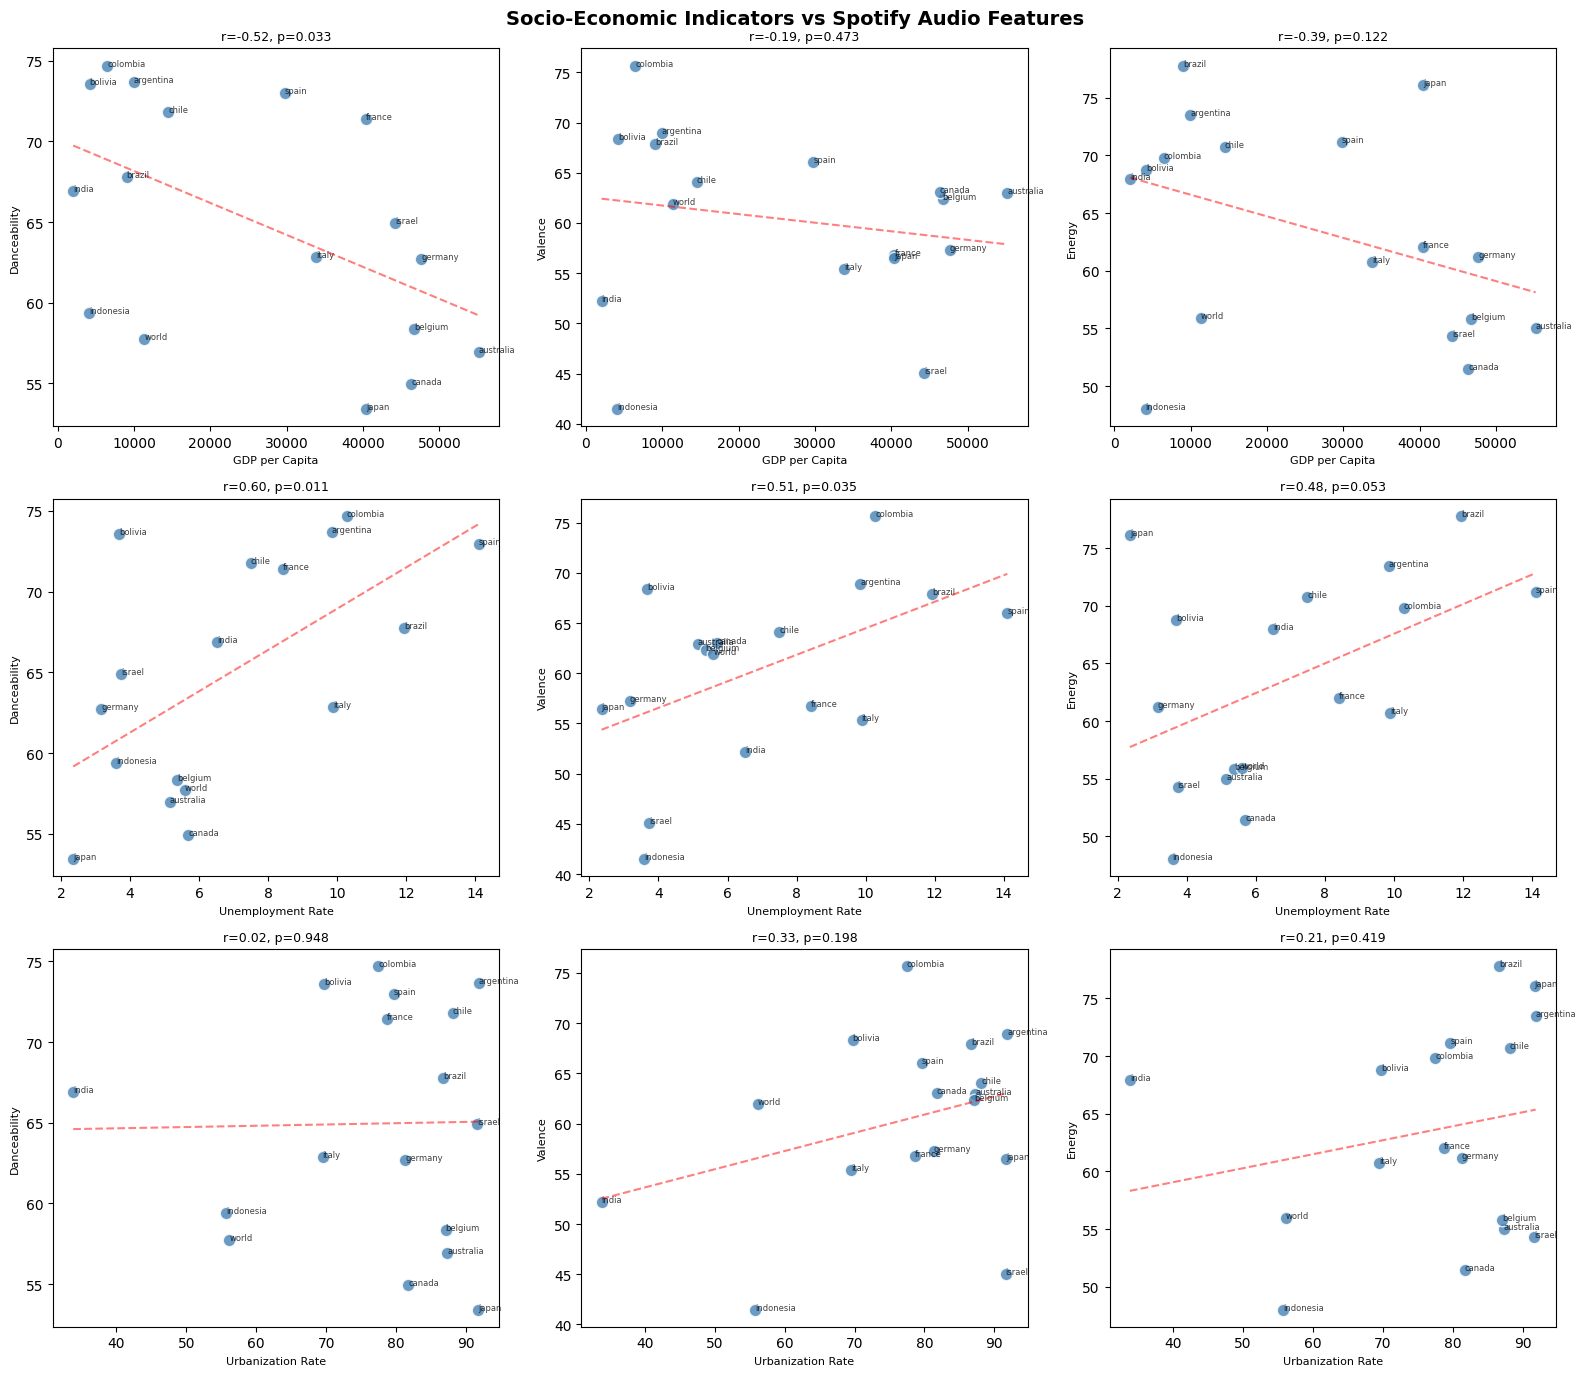

eda_plots.png saved.


In [42]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle("Socio-Economic Indicators vs Spotify Audio Features", fontsize=14, fontweight="bold")

econ_vars = [
    ("gdp_per_capita",    "GDP per Capita"),
    ("unemployment_rate", "Unemployment Rate"),
    ("urbanization_rate", "Urbanization Rate")
]
audio_vars = [
    ("dnce", "Danceability"),
    ("val",  "Valence"),
    ("nrgy", "Energy")
]

for i, (econ_col, econ_label) in enumerate(econ_vars):
    for j, (audio_col, audio_label) in enumerate(audio_vars):
        ax = axes[i][j]
        ax.scatter(df_merged2[econ_col], df_merged2[audio_col],
                   s=80, alpha=0.8, color="steelblue", edgecolors="white")

        for _, row in df_merged2.iterrows():
            ax.annotate(row["country"], (row[econ_col], row[audio_col]),
                        fontsize=6, alpha=0.75)

        # Trendline
        mask = df_merged2[[econ_col, audio_col]].notna().all(axis=1)
        x = df_merged2.loc[mask, econ_col]
        y = df_merged2.loc[mask, audio_col]
        z = np.polyfit(x, y, 1)
        p_line = np.poly1d(z)
        ax.plot(np.sort(x), p_line(np.sort(x)), "r--", alpha=0.5)

        r, p = stats.pearsonr(x, y)
        ax.set_xlabel(econ_label, fontsize=8)
        ax.set_ylabel(audio_label, fontsize=8)
        ax.set_title(f"r={r:.2f}, p={p:.3f}", fontsize=9)

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("eda_plots.png saved.")

In [22]:
print("=" * 55)
print("HYPOTHESIS TESTS")
print("=" * 55)

test_pairs = [
    ("gdp_per_capita",    "dnce", "H1: GDP per Capita -> Danceability"),
    ("gdp_per_capita",    "val",  "H2: GDP per Capita -> Valence"),
    ("gdp_per_capita",    "nrgy", "H3: GDP per Capita -> Energy"),
    ("unemployment_rate", "dnce", "H4: Unemployment Rate -> Danceability"),
    ("unemployment_rate", "val",  "H5: Unemployment Rate -> Valence"),
    ("urbanization_rate", "dnce", "H6: Urbanization Rate -> Danceability"),
]

for econ, audio, label in test_pairs:
    mask = df_merged[[econ, audio]].notna().all(axis=1)
    x = df_merged.loc[mask, econ]
    y = df_merged.loc[mask, audio]
    r, p = stats.pearsonr(x, y)
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"\n{label}")
    print(f"  r={r:.3f}, p={p:.4f} -> {sig}")

print("\n" + "=" * 55)
print("Relationships with p < 0.05 are statistically significant.")
print("This means the correlation is unlikely to be due to chance.")

HYPOTHESIS TESTS

H1: GDP per Capita -> Danceability
  r=-0.519, p=0.0328 -> SIGNIFICANT

H2: GDP per Capita -> Valence
  r=-0.187, p=0.4730 -> not significant

H3: GDP per Capita -> Energy
  r=-0.390, p=0.1218 -> not significant

H4: Unemployment Rate -> Danceability
  r=0.597, p=0.0114 -> SIGNIFICANT

H5: Unemployment Rate -> Valence
  r=0.514, p=0.0350 -> SIGNIFICANT

H6: Urbanization Rate -> Danceability
  r=0.017, p=0.9476 -> not significant

Relationships with p < 0.05 are statistically significant.
This means the correlation is unlikely to be due to chance.
